<a href="https://colab.research.google.com/github/KarthikRamu-gif/electricity-deman-forecasting/blob/main/notebooks/01_group_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electricity Demand Forecasting Project
## Group members
- Karthik
- Divyank
- Bilal

## Group Project Overview

This project focuses on forecasting hourly electricity consumption using historical energy demand data from the AEP region of the PJM Interconnection power grid.

The objective is to analyse temporal patterns in electricity demand and develop forecasting models capable of predicting future electricity consumption using classical statistical, machine learning, and deep learning approaches.

The project includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Forecasting problem definition
- Validation strategy
- Model evaluation

The dataset used is the AEP Hourly Energy Consumption dataset obtained from Kaggle.

# Data Loading and Inspection

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (15,5)

In [ ]:
df = pd.read_csv('/content/AEP_hourly.csv')

In [ ]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


# Datetime Processing


In [ ]:
# Convert Datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set Datetime as index
df.set_index('Datetime', inplace=True)

# Sort values by time
df = df.sort_index()

# Preview dataset
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


# Time Series Visualization

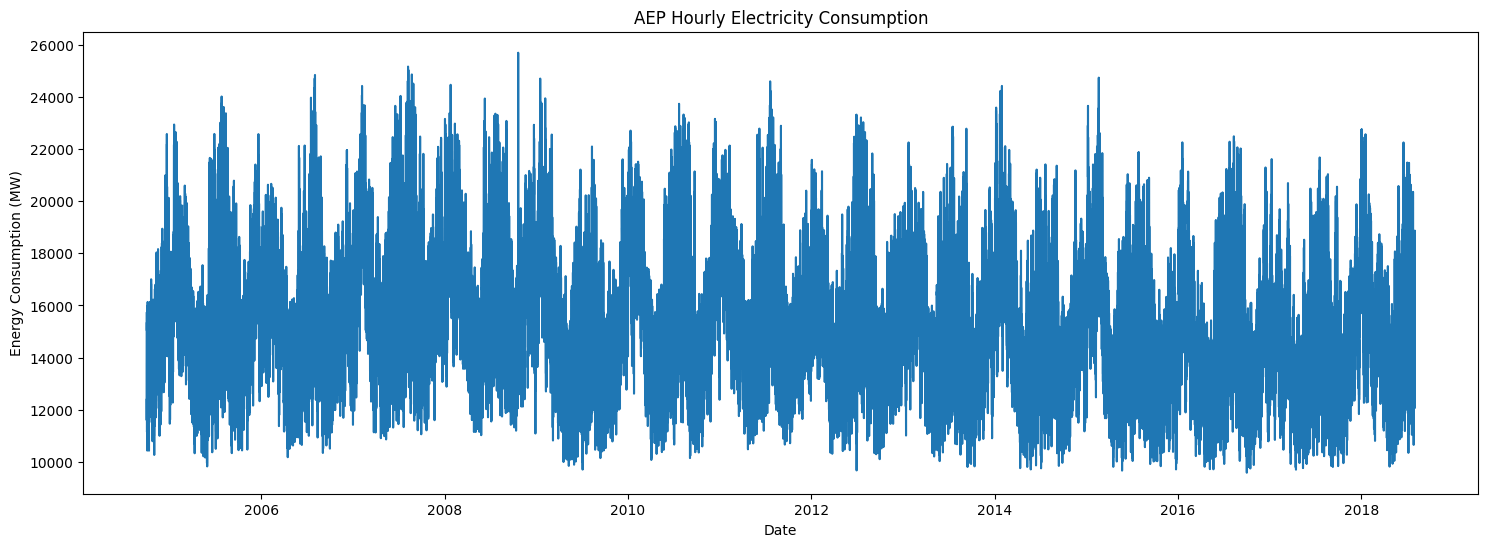

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(df.index, df['AEP_MW'])

plt.title('AEP Hourly Electricity Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')

plt.show()

In [ ]:
df.isnull().sum()

,0
AEP_MW,0


# Data Quality Checks

In [ ]:
print("Duplicate timestamps:", df.index.duplicated().sum())

Duplicate timestamps: 4


# Removing Duplicate Timestamps

In [ ]:
# Remove duplicate timestamps
df = df[~df.index.duplicated(keep='first')]

# Verify duplicates removed
print("Duplicate timestamps:", df.index.duplicated().sum())

Duplicate timestamps: 0


# Basic Statistical Summary

In [ ]:
df.describe()

,AEP_MW
count,121269.000000
mean,15499.652351
std,2591.321478
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


# Daily Seasonality Analysis

This section analyses the average electricity demand across different hours of the day to identify recurring daily consumption patterns.

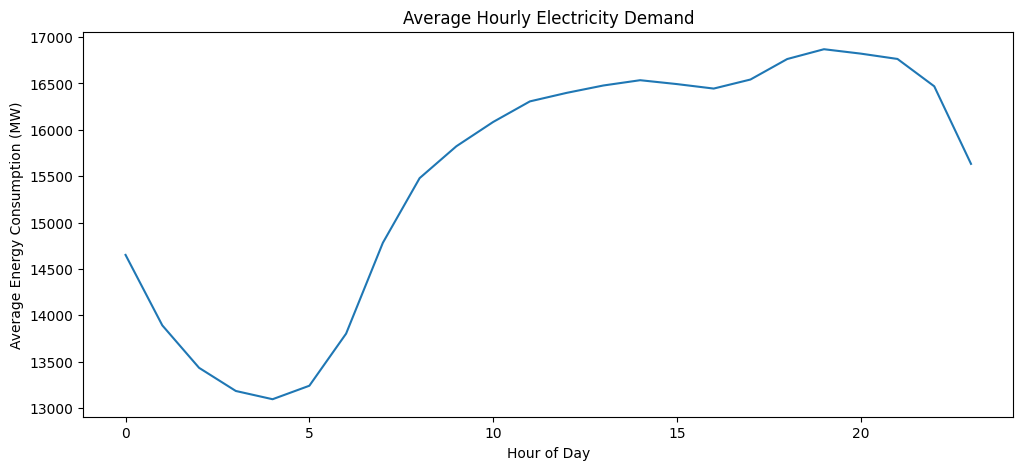

In [ ]:
# Average demand by hour
hourly_pattern = df.groupby(df.index.hour)['AEP_MW'].mean()

# Plot hourly seasonality
plt.figure(figsize=(12,5))

hourly_pattern.plot()

plt.title('Average Hourly Electricity Demand')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')

plt.show()

As we can see from the daily graph that the consumption is lowest during the early hours 12am to 5am, it keeps on decreasing. After that the consumption starts increasing as people wake up and start using appliances. The peak time of usage is around 6pm to 9pm and then it starts decreasing again.

# Weekly Seasonality Analysis

This section analyses electricity demand patterns across different days of the week to identify weekly seasonal behaviour.

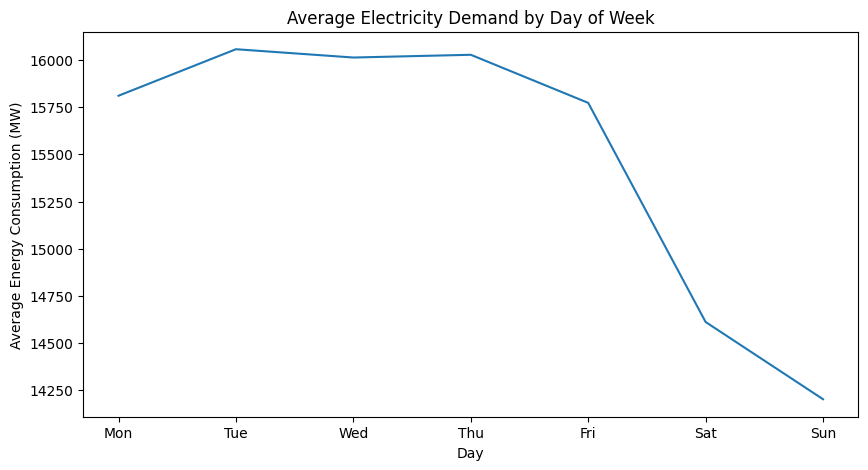

In [ ]:
# Average demand by day of week
weekly_pattern = df.groupby(df.index.dayofweek)['AEP_MW'].mean()

# Day labels
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot weekly seasonality
plt.figure(figsize=(10,5))

plt.plot(days, weekly_pattern)

plt.title('Average Electricity Demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Energy Consumption (MW)')

plt.show()

From the weekly graph we can see that during weekdays electricity demand is high because of offices, industries and other usages. After that during the weekend the consumption is low due to less usage in commercial sector and industries.

# Monthly Trend Analysis

This section analyses electricity demand patterns across different months to identify long-term seasonal trends.

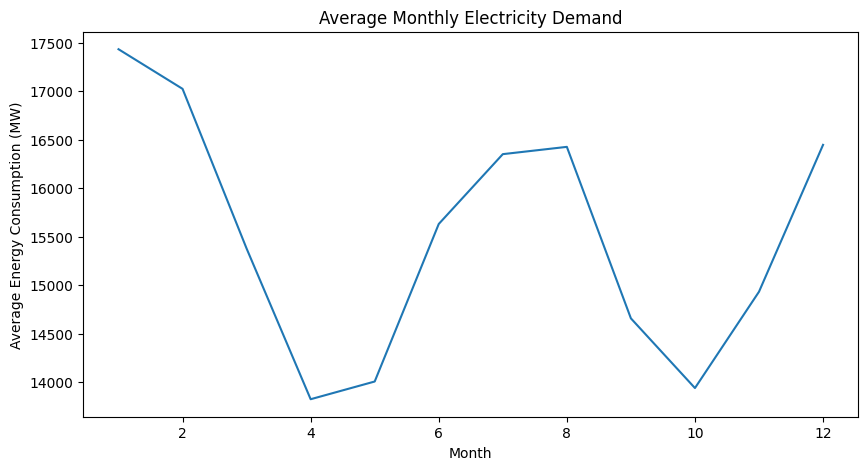

In [ ]:
# Average demand by month
monthly_pattern = df.groupby(df.index.month)['AEP_MW'].mean()

# Plot monthly trend
plt.figure(figsize=(10,5))

monthly_pattern.plot()

plt.title('Average Monthly Electricity Demand')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')

plt.show()

The monthly trend shows a mixed pattern in electricity demand:
1. From January to April, demand is declining, which may be due to reduced heating needs after winter.
2. From April to August, demand starts increasing, likely because of higher cooling usage during warmer months.
3. Between August and October, there is a slight decrease, possibly due to milder weather and reduced air conditioning usage.
4. From October to December, demand rises again as colder weather increases heating and indoor electricity consumption.

This pattern reflects how seasonal weather changes strongly influence electricity usage throughout the year.

# Seasonal Decomposition

Seasonal decomposition separates the time series into:
- Trend component
- Seasonal component
- Residual component

This helps identify underlying temporal structures in the electricity demand data.

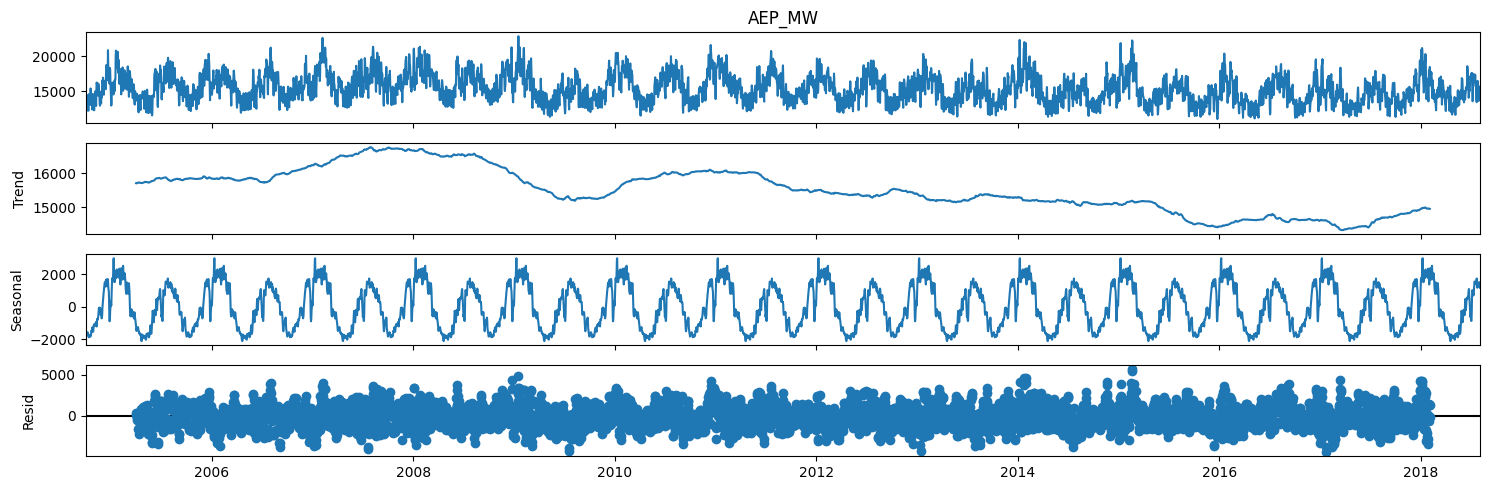

In [ ]:
# Resample to daily averages
daily_df = df.resample('D').mean()

# Perform decomposition
decomposition = seasonal_decompose(
    daily_df['AEP_MW'],
    model='additive',
    period=365
)

# Plot decomposition
decomposition.plot()

plt.show()

# Forecasting Strategy and Model Selection

## Model Selection Justification

The exploratory data analysis and the seasonality analysis showed a high seasonal behaviour, a high trend component and a high temporal pattern in the electricity demand data.

The cycle of electricity consumption was evident in the visualizations at hourly and weekly intervals, and the decomposition analysis was able to identify the trend and seasonality in the time series data.

Depending on these results, different forecasting methods were chosen to assess the accuracy of various model types in their ability to predict the seasonal and temporal characteristics.

The forecasting model used as a baseline model was a Seasonal Naive forecasting method as there was strong repeating seasonal pattern in the data.

The SARIMA model was chosen because it is a model that is specifically used for time series data that have trend and seasonality components.

To handle these complexities and nonlinear relationships in the electricity demand data, the XGBoost model was used.

Deep learning methods are suitable for time series forecasting tasks due to their ability to capture temporal relationships and sequential patterns in time series, hence, the choice of the LSTM model.

To ensure the fair comparison, the same validation strategy and forecasting metrics were used for all the models.

# Forecasting Problem Definition

The objective of this project is to forecast future hourly electricity consumption using historical energy demand data.

## Forecasting Setup

- Target Variable: AEP_MW
- Forecast Type: Univariate Time Series Forecasting
- Forecast Frequency: Hourly
- Forecast Horizon: Next 24 Hours

The forecasting models developed in this project will be evaluated using consistent validation and evaluation strategies.

# Validation Strategy

To preserve the temporal structure of the data, a chronological train-test split strategy will be used.

## Data Splitting Approach

- Training Set: 80%
- Testing Set: 20%

Random shuffling is avoided because it would break the time dependency structure required for forecasting tasks.

In [ ]:
# Train-test split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Display shapes
print("Training Set Shape:", train.shape)
print("Testing Set Shape:", test.shape)

Training Set Shape: (97015, 1)
Testing Set Shape: (24254, 1)


# Evaluation Metrics

The forecasting models in this project will be evaluated using multiple performance metrics to ensure comprehensive assessment of prediction accuracy.

## Metrics Used

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

These metrics provide insights into forecast error magnitude, model stability, and overall predictive performance.

# Group Discussion of Forecasting Models



## Discussion

Three different forecasting models were developed and tested for electricity demand forecasting:

- SARIMA
- XGBoost
- LSTM

The SARIMA model was able to capture overall trend and seasonal behaviour in the dataset. But it did not perform as well as the other models in predicting. A possible explanation is that the daily resampling carried out to reduce the complexity of the computation (and hence the number of samples) resulted in the loss of the important hourly variations in the original data.

The errors in the forecasting with XGBoost were significantly lower than those in the baseline forecasting approach. The model achieved good learning performance for the nonlinear relationship and for the short-term variation of the electricity demand data. The forecast visualization also demonstrated that the expected values were close to the actual demand values.

The LSTM model had the lowest MAE and RMSE values among all models indicating the best forecasting performance. The model was able to replicate the short-term fluctuations in the data and the seasonal behaviour over time. The visualisation analysis revealed that the LSTM predictions were quite similar to the actual values of electricity demand in the entire forecast horizon.

The comparison of the models demonstrates that the deep learning and machine learning models were capable of predicting the data better than the traditional statistical SARIMA model for this data.

Simpler baseline forecasting techniques were also found to be competitive in the presence of strong seasonality in time series data, which was also shown during the project.

## Conclusion

In this project, various electricity demand forecasting methods were investigated, based on the AEP hourly electricity consumption dataset.

The first step in the group's approach was to perform exploratory data analysis, preprocessing, trend analysis and seasonality analysis to gain a better understanding of the dataset characteristics and define the forecasting problem.

Three forecasting models were then taken and tested separately:
- SARIMA
- XGBoost
- LSTM

Evaluation metrics like MAE and RMSE were used to compare all the models with baseline forecasting methods.

The findings revealed that the LSTM model had the best forecasting results, followed by the model of XGBoost and the SARIMA gave comparatively high forecasting errors.

The project emphasized the need for making decisions in the pre-processing stage, choosing models, pre-processing the models, methods for model validation, and the computational aspects of time series forecasting.

The project overall showed that advanced machine learning and deep learning methods can deliver very accurate predictions of electricity demand data with a strong seasonal and nonlinear behavior.

**LINK**

Following is the link for the github repository:
https://github.com/KarthikRamu-gif/electricity-deman-forecasting